<a href="https://colab.research.google.com/github/RamitSachdev/IML_Assignment1/blob/main/IML_A1_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# Loading the data and then splitting it to train and test

diabetes_data = load_diabetes(as_frame=True)
data = diabetes_data.frame

X = data.drop(columns=["target"]).values
y = data["target"].values

np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(0.8 * len(X))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")

Training samples: 353, Test samples: 89
Number of features: 10


In [11]:
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def build_tree(self, X, y, depth=0):
        n_samples = len(y)


        if (self.max_depth is not None and depth >= self.max_depth) or \
           (n_samples < self.min_samples_split):
            return {"leaf": True, "value": np.mean(y)}

        best_feature, best_threshold = self._best_split(X, y)


        if best_feature is None:
            return {"leaf": True, "value": np.mean(y)}

        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask


        if left_mask.sum() == 0 or right_mask.sum() == 0:
            return {"leaf": True, "value": np.mean(y)}

        left_subtree  = self.build_tree(X[left_mask],  y[left_mask],  depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            "leaf": False,
            "feature": best_feature,
            "threshold": best_threshold,
            "left": left_subtree,
            "right": right_subtree
        }

    def _best_split(self, X, y):
        best_mse = np.inf
        best_feature = None
        best_threshold = None

        n_samples, n_features = X.shape

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask  = X[:, feature] <= threshold
                right_mask = ~left_mask

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                mse = self._weighted_mse(y[left_mask], y[right_mask])
                if mse < best_mse:
                    best_mse = mse
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _weighted_mse(self, left_y, right_y):
        n = len(left_y) + len(right_y)
        mse_left  = np.var(left_y)  * len(left_y)  / n
        mse_right = np.var(right_y) * len(right_y) / n
        return mse_left + mse_right

    def fit(self, X, y):
        self.tree = self.build_tree(X, y)

    def predict(self, x):
        node = self.tree
        while not node["leaf"]:
            if x[node["feature"]] <= node["threshold"]:
                node = node["left"]
            else:
                node = node["right"]
        return node["value"]

    def predict_all(self, X):
        return np.array([self.predict(x) for x in X])

In [12]:
class RandomForest:
    def __init__(self, n_trees=10, max_depth=None, min_samples_split=2,
                 max_features=None, max_samples=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.max_samples = max_samples
        self.trees = []
        self.feature_indices = []

    def build_forest(self, X, y):
        n_samples, n_features = X.shape


        if self.max_features is None:
            self.max_features = max(1, int(np.sqrt(n_features)))
        if self.max_samples is None:
            self.max_samples = max(1, int(0.8 * n_samples))

        self.trees = []
        self.feature_indices = []

        for _ in range(self.n_trees):

            sample_idx = np.random.choice(n_samples, self.max_samples, replace=False)

            feat_idx = np.random.choice(n_features, self.max_features, replace=False)

            X_sub = X[sample_idx][:, feat_idx]
            y_sub = y[sample_idx]

            tree = DecisionTree(max_depth=self.max_depth,
                                min_samples_split=self.min_samples_split)
            tree.fit(X_sub, y_sub)

            self.trees.append(tree)
            self.feature_indices.append(feat_idx)

    def predict(self, x):

        preds = []
        for tree, feat_idx in zip(self.trees, self.feature_indices):
            preds.append(tree.predict(x[feat_idx]))
        return np.mean(preds)

    def predict_all(self, X):
        return np.array([self.predict(x) for x in X])



In [14]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


dt = DecisionTree(max_depth=5, min_samples_split=5)
dt.fit(X_train, y_train)

dt_train_preds = dt.predict_all(X_train)
dt_test_preds  = dt.predict_all(X_test)

dt_train_mse = mse(y_train, dt_train_preds)
dt_test_mse  = mse(y_test,  dt_test_preds)

print("Single Decision Tree")
print(f"Train MSE: {dt_train_mse:.2f}")
print(f"Test  MSE: {dt_test_mse:.2f}")










rf = RandomForest(n_trees=50, max_depth=5, min_samples_split=5)
rf.build_forest(X_train, y_train)

rf_train_preds = rf.predict_all(X_train)
rf_test_preds  = rf.predict_all(X_test)

rf_train_mse = mse(y_train, rf_train_preds)
rf_test_mse  = mse(y_test,  rf_test_preds)

print("Random Forest (50 trees))")
print(f"Train MSE: {rf_train_mse:.2f}")
print(f"Test  MSE: {rf_test_mse:.2f}")

#Help taken from GPT to debug and fix RandomForest

Single Decision Tree
Train MSE: 1852.91
Test  MSE: 5030.46
Random Forest (50 trees))
Train MSE: 2182.54
Test  MSE: 3838.75


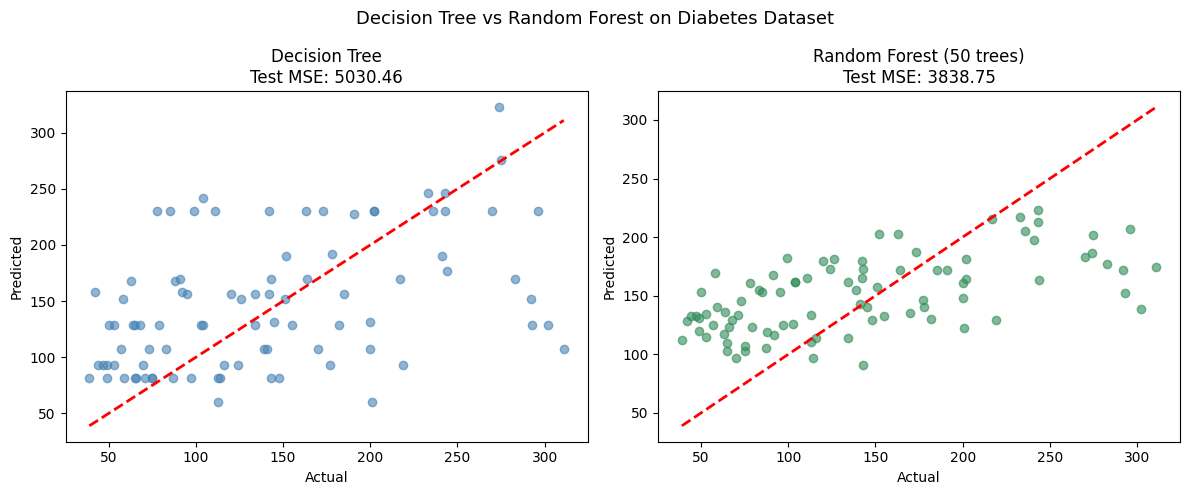

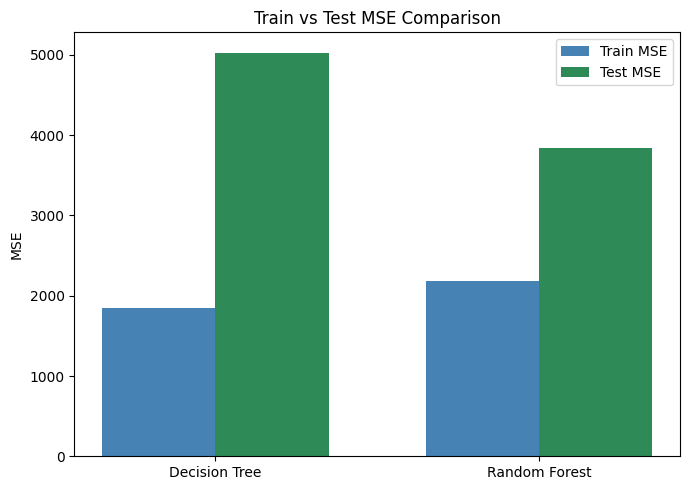

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree predictions vs actual
axes[0].scatter(y_test, dt_test_preds, alpha=0.6, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Decision Tree\nTest MSE: {dt_test_mse:.2f}")

# Random Forest predictions vs actual
axes[1].scatter(y_test, rf_test_preds, alpha=0.6, color='seagreen')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
axes[1].set_title(f"Random Forest (50 trees)\nTest MSE: {rf_test_mse:.2f}")

plt.suptitle("Decision Tree vs Random Forest on Diabetes Dataset", fontsize=13)
plt.tight_layout()
plt.savefig("comparison.png", dpi=150)
plt.show()

#comparison (done with the help of claude)
labels = ['Decision Tree', 'Random Forest']
train_mses = [dt_train_mse, rf_train_mse]
test_mses  = [dt_test_mse,  rf_test_mse]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, train_mses, width, label='Train MSE', color='steelblue')
ax.bar(x + width/2, test_mses,  width, label='Test MSE',  color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("MSE")
ax.set_title("Train vs Test MSE Comparison")
ax.legend()
plt.tight_layout()
plt.savefig("mse_comparison.png", dpi=150)
plt.show()